In [ ]:
# First things first i will import all the libraries so i wont have to import them later on.
# these libraries will be used for data manipulation
import pandas as pd
import numpy as np

# these libraries will be used for data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# this library will be used for statistics stuff
from scipy.stats import pearsonr

# these libraries will be used for ML/regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# this library will be used for importing files
from google.colab import files


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# to import our dataset file
uploaded = files.upload()

Saving Air dataset.csv to Air dataset.csv


In [ ]:
# load the file
df = pd.read_csv("Air dataset.csv")

In [ ]:
# understand the dataset using the following:
print("Dataset shape:")
print(df.shape)
print("\nColumn names:")
print(df.columns)
print("\nDataset information:")
df.info()
df.head()

Dataset shape:
(14100, 10)

Column names:
Index(['datetime', 'PM10', 'PM2.5', 'temperature', 'rain', 'pressure',
       'precipitation', 'wind_speed', 'clouds', 'wind_direction'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14100 entries, 0 to 14099
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   datetime        14100 non-null  object 
 1   PM10            14030 non-null  float64
 2   PM2.5           14030 non-null  float64
 3   temperature     13885 non-null  float64
 4   rain            13885 non-null  float64
 5   pressure        13870 non-null  float64
 6   precipitation   13885 non-null  float64
 7   wind_speed      13885 non-null  float64
 8   clouds          13885 non-null  object 
 9   wind_direction  7164 non-null   object 
dtypes: float64(7), object(3)
memory usage: 1.1+ MB


,datetime,PM10,PM2.5,temperature,rain,pressure,precipitation,wind_speed,clouds,wind_direction
0,02/05/2024 20:00,3.0,2.0,11.0,0.0,1008.0,87.0,3.0,mostly cloudy,NaN
1,02/05/2024 21:00,6.0,3.0,11.0,0.0,1008.0,87.0,3.0,partly cloudy,NaN
2,02/05/2024 22:00,7.0,3.0,11.0,0.4,1009.0,84.0,13.0,partly cloudy,NaN
3,02/05/2024 23:00,7.0,4.0,10.0,0.0,1009.0,95.0,4.0,partly cloudy,NaN
4,03/05/2024 00:00,7.0,3.0,10.0,0.0,1009.0,93.0,3.0,partly cloudy,NaN


In [ ]:
# now i need to convert datetime into a format Python can understand
df["datetime"] = pd.to_datetime(df["datetime"], dayfirst=True)
df = df.sort_values("datetime")
df.head()
# for example: from 02/05/2024 20:00:00 to 2024-05-02 20:00:00

,datetime,PM10,PM2.5,temperature,rain,pressure,precipitation,wind_speed,clouds,wind_direction
0,2024-05-02 20:00:00,3.0,2.0,11.0,0.0,1008.0,87.0,3.0,mostly cloudy,NaN
1,2024-05-02 21:00:00,6.0,3.0,11.0,0.0,1008.0,87.0,3.0,partly cloudy,NaN
2,2024-05-02 22:00:00,7.0,3.0,11.0,0.4,1009.0,84.0,13.0,partly cloudy,NaN
3,2024-05-02 23:00:00,7.0,4.0,10.0,0.0,1009.0,95.0,4.0,partly cloudy,NaN
4,2024-05-03 00:00:00,7.0,3.0,10.0,0.0,1009.0,93.0,3.0,partly cloudy,NaN


In [ ]:
# now we need to check for missing values before analysis
missing = df.isnull().sum()
missing_percentage = (missing / len(df))*100
missing_table = pd.DataFrame({"Missing Values": missing, "Percentage": missing_percentage})
missing_table

,Missing Values,Percentage
datetime,0,0.000000
PM10,70,0.496454
PM2.5,70,0.496454
temperature,215,1.524823
rain,215,1.524823
pressure,230,1.631206
precipitation,215,1.524823
wind_speed,215,1.524823
clouds,215,1.524823
wind_direction,6936,49.191489


**wind_direction:** wind_direction has around 50% missing value so filling it would introduce too much artificial and inaccurate data so i will remove that column from my dataset

**PM2.5 and PM10:** As these two are my target variable so that means i cannot guess these values because it will then affect my regression results so i will remove the rows that contain null values for either PM2.5 or PM10.

**Weather variables:** Weather variables change gradually over time so i think interpolation would be reasonable for small gaps

In [ ]:
df.isnull().sum()
df = df.drop(columns=["wind_direction"], errors="ignore") # as it removed the column when i ran it first time so errors="ignore" will ignore the error if ran 2nd or any other time
df = df.dropna(subset=["PM2.5", "PM10"])
weather_columns = ["temperature", "rain", "precipitation", "pressure", "wind_speed", "clouds"]
df[weather_columns] = df[weather_columns].interpolate()
print("After cleaning:", df.shape)

After cleaning: (14030, 9)


/tmp/ipykernel_1525/3931882334.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[weather_columns] = df[weather_columns].interpolate()


Before Cleaning: (14100, 10)

After Cleaning: (14030, 9)

In [ ]:
# i will check for negative values just in case there are any except for temperature values
numeric_columns = df.select_dtypes(include=np.number).columns
for column in numeric_columns:
    negative = (df[column] < 0).sum()
    print(column, "negative values:", negative)

PM10 negative values: 0
PM2.5 negative values: 0
temperature negative values: 961
rain negative values: 0
pressure negative values: 0
precipitation negative values: 0
wind_speed negative values: 0


The Data is **Clean** now as it does not contain:
*   Any missing values
*   Any negative values (temperature is an exception)

so i can now move onto the statistical stuff



In [ ]:
# i will now create a table for descriptive stats like mean, std, min, max and quartiles
descriptive_stats = df.describe().T

descriptive_stats

,count,mean,min,25%,50%,75%,max,std
datetime,14030,2025-02-20 13:02:19.586600192,2024-05-02 20:00:00,2024-09-27 03:15:00,2025-02-20 07:30:00,2025-07-16 15:45:00,2025-12-11 07:00:00,NaN
PM10,14030.0,19.275339,2.0,10.0,15.0,24.0,139.0,14.607057
PM2.5,14030.0,13.505773,2.0,6.0,10.0,17.0,134.0,12.257156
temperature,14030.0,13.210228,-7.0,6.0,14.0,20.0,35.0,8.777174
rain,14030.0,0.165132,0.0,0.0,0.0,0.0,22.1,0.856847
pressure,14030.0,1017.947755,988.0,1013.0,1017.0,1022.0,1042.0,7.345501
precipitation,14030.0,79.481041,21.0,68.0,84.0,94.0,100.0,17.117164
wind_speed,14030.0,4.96422,0.0,1.0,3.0,7.0,33.0,4.621538


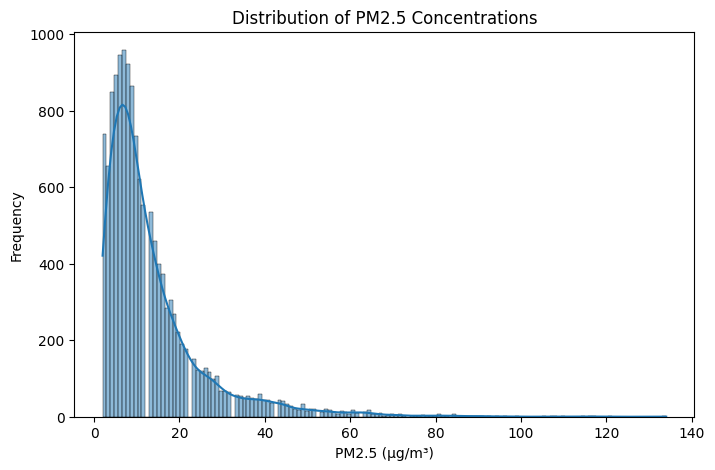

In [ ]:
# now i will create histogram distribution for PM2.5
plt.figure(figsize=(8,5))
sns.histplot(df["PM2.5"], kde=True)
plt.title("Distribution of PM2.5 Concentrations")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frequency")
plt.show()

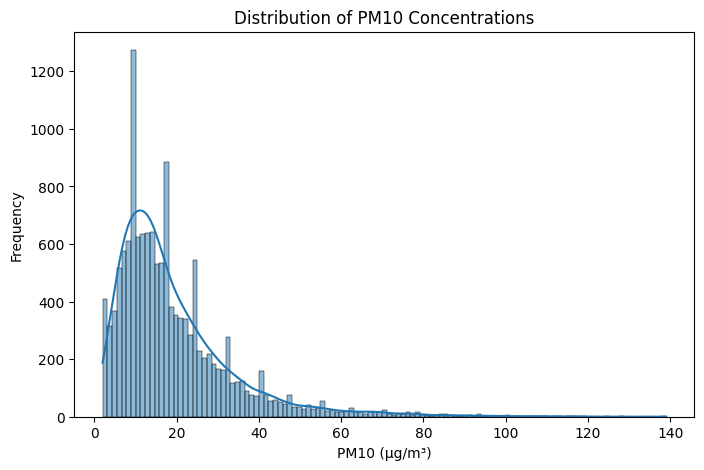

In [ ]:
# same for PM10
plt.figure(figsize=(8,5))
sns.histplot(df["PM10"], kde=True)
plt.title("Distribution of PM10 Concentrations")
plt.xlabel("PM10 (µg/m³)")
plt.ylabel("Frequency")
plt.show()

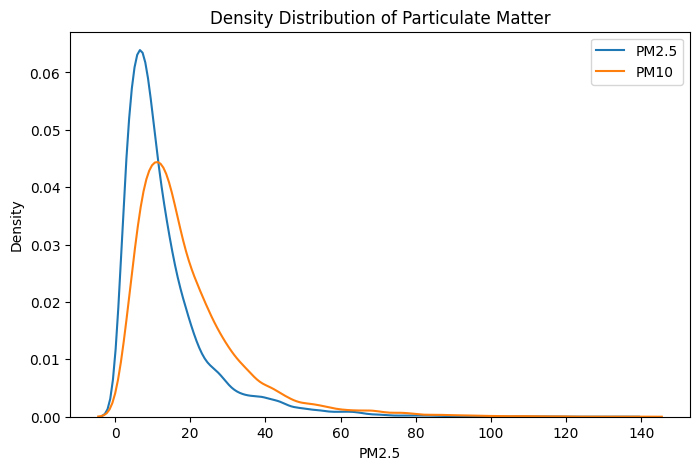

In [ ]:
# now a density plot to compare both PM2.5 and PM10
plt.figure(figsize=(8,5))
sns.kdeplot(df["PM2.5"], label="PM2.5")
sns.kdeplot(df["PM10"], label="PM10")
plt.title("Density Distribution of Particulate Matter")
plt.legend()
plt.show()

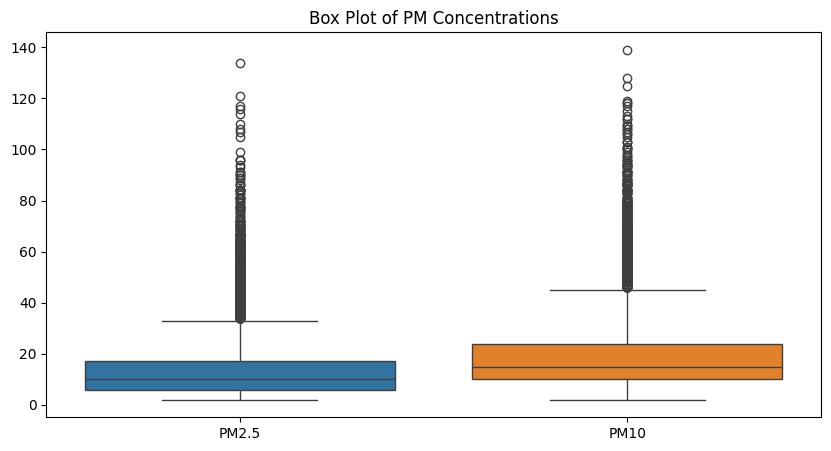

In [ ]:
# a box plot of PM2.5 and PM10 would also be beneficial to compare averages and outliers.
plt.figure(figsize=(10,5))
sns.boxplot(data=df[["PM2.5","PM10"]])
plt.title("Box Plot of PM Concentrations")
plt.show()

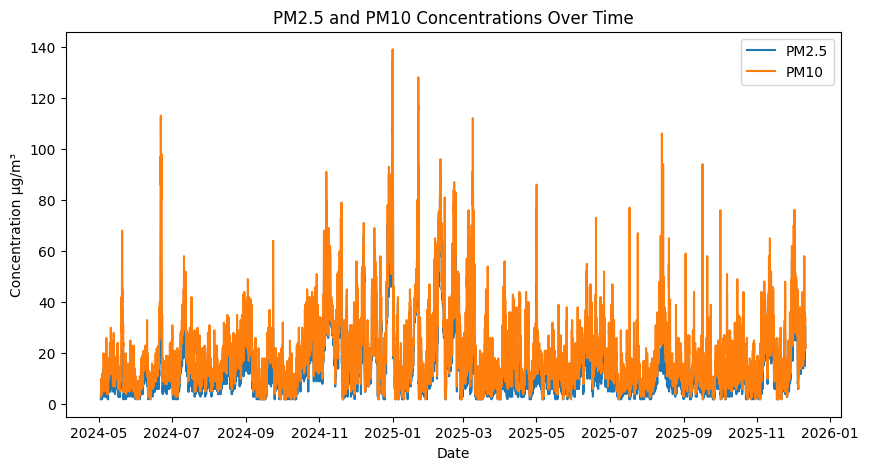

In [ ]:
# to compare concentrations of PM2.5 and PM10 over time
plt.figure(figsize=(10,5))
plt.plot(df["datetime"], df["PM2.5"], label="PM2.5")
plt.plot(df["datetime"], df["PM10"], label="PM10")
plt.title("PM2.5 and PM10 Concentrations Over Time")
plt.xlabel("Date")
plt.ylabel("Concentration µg/m³")
plt.legend()
plt.show()

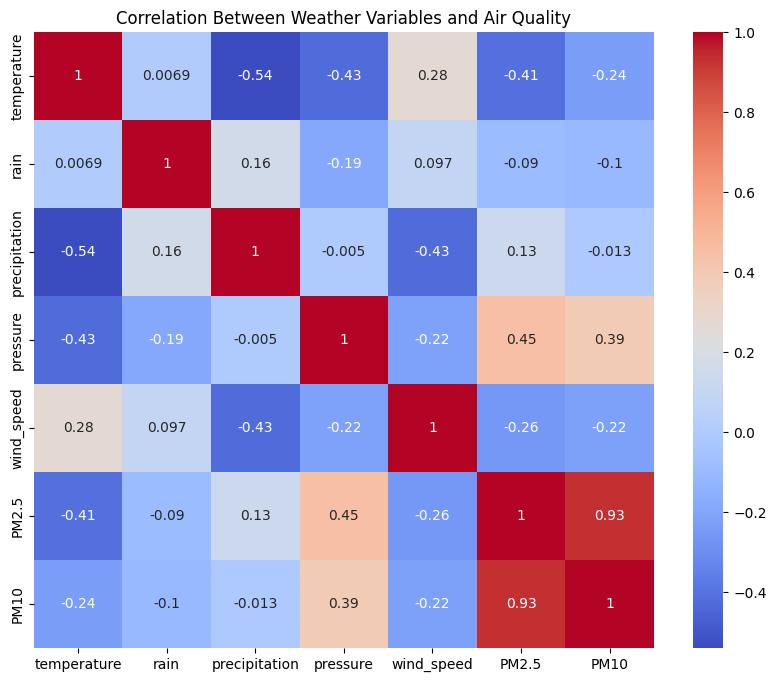

In [ ]:
# the most important visualisation - Correlation Matrix
weather_variables = ["temperature","rain","precipitation","pressure","wind_speed","PM2.5","PM10"]
correlation_matrix = df[weather_variables].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Between Weather Variables and Air Quality")
plt.show()


In [ ]:
correlation_matrix

,temperature,rain,precipitation,pressure,wind_speed,PM2.5,PM10
temperature,1.000000,0.006883,-0.540564,-0.430397,0.275983,-0.412734,-0.235336
rain,0.006883,1.000000,0.161822,-0.189779,0.096594,-0.090402,-0.104990
precipitation,-0.540564,0.161822,1.000000,-0.004975,-0.430382,0.131318,-0.013123
pressure,-0.430397,-0.189779,-0.004975,1.000000,-0.219079,0.452068,0.385613
wind_speed,0.275983,0.096594,-0.430382,-0.219079,1.000000,-0.262695,-0.222410
PM2.5,-0.412734,-0.090402,0.131318,0.452068,-0.262695,1.000000,0.928970
PM10,-0.235336,-0.104990,-0.013123,0.385613,-0.222410,0.928970,1.000000


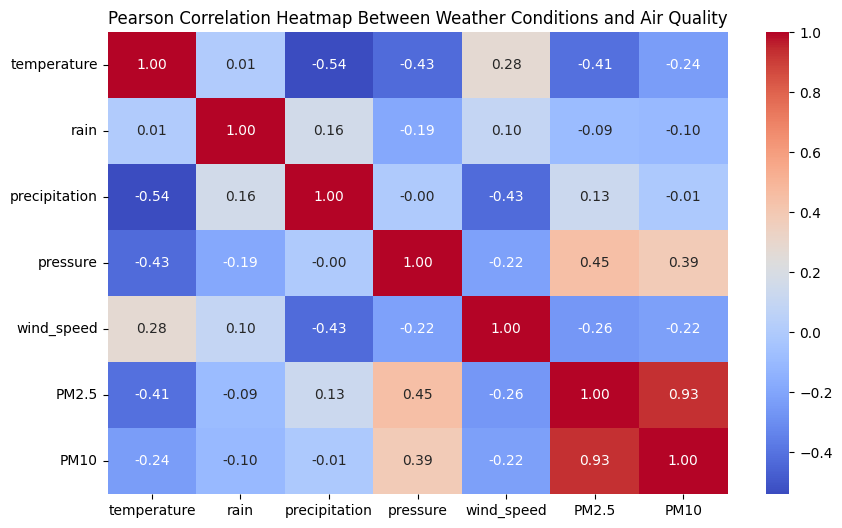

In [ ]:
# this is the pearson correlation table showing relationships between weather variables and air quality
targets = ["PM2.5", "PM10"]
weather = ["temperature", "rain", "precipitation", "pressure", "wind_speed",]
results=[]
for variable in weather:
    for target in targets:
        r,p = pearsonr(df[variable], df[target])
        results.append({"Variable":variable, "Target":target, "Correlation":r, "p-value":p})

correlation_results = pd.DataFrame(results)
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Heatmap Between Weather Conditions and Air Quality")
plt.show()

In [ ]:
correlation_results

,Variable,Target,Correlation,p-value
0,temperature,PM2.5,-0.412734,0.000000e+00
1,temperature,PM10,-0.235336,7.933021e-176
2,rain,PM2.5,-0.090402,7.437929e-27
3,rain,PM10,-0.104990,1.098709e-35
4,precipitation,PM2.5,0.131318,5.264141e-55
5,precipitation,PM10,-0.013123,1.201031e-01
6,pressure,PM2.5,0.452068,0.000000e+00
7,pressure,PM10,0.385613,0.000000e+00
8,wind_speed,PM2.5,-0.262695,3.913068e-220
9,wind_speed,PM10,-0.222410,8.827995e-157


In [ ]:
# write a function for regression plot so we can use it multiple times with multiple variables
def regression_plot(x,y):
    plt.figure(figsize=(10,5))
    sns.regplot(data=df,x=x,y=y,scatter_kws={"alpha":0.5})
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()

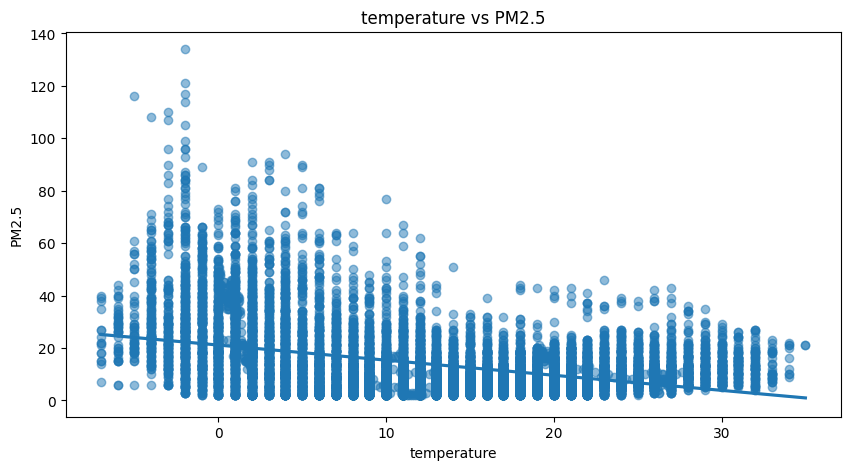

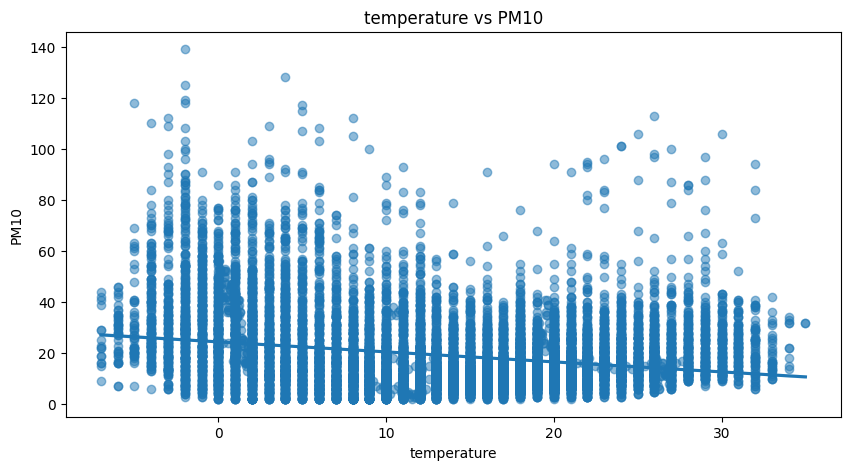

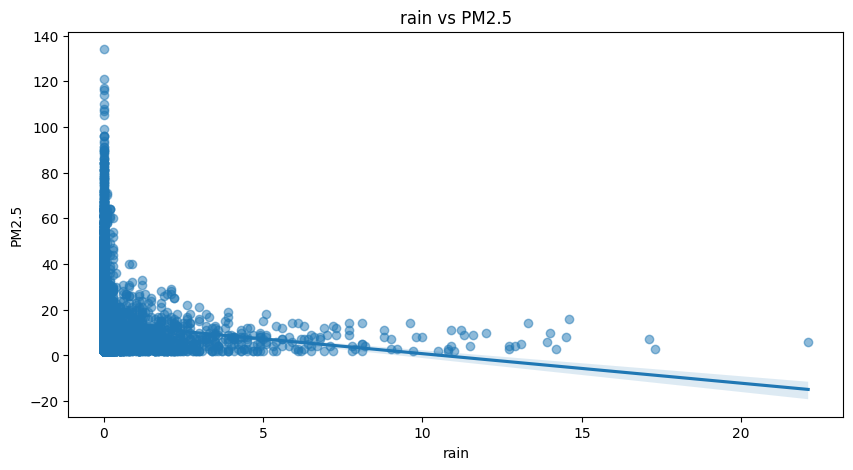

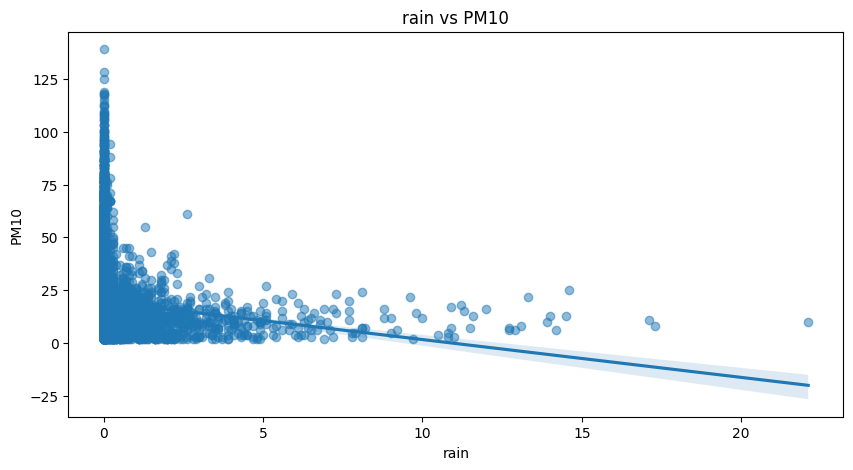

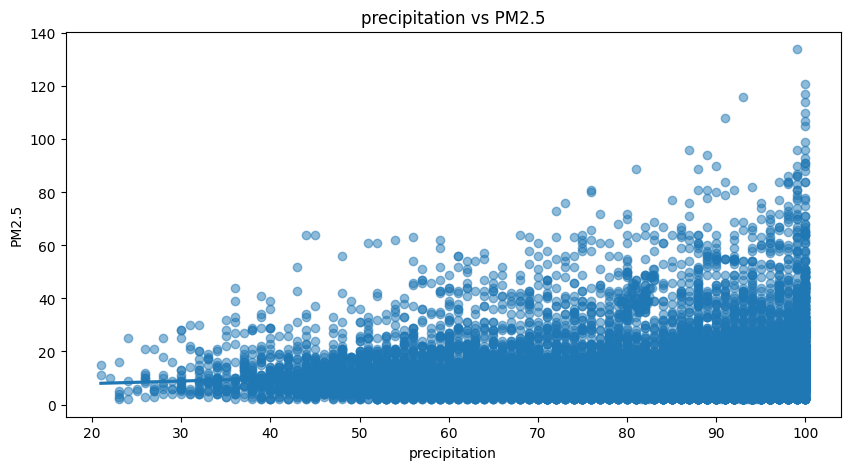

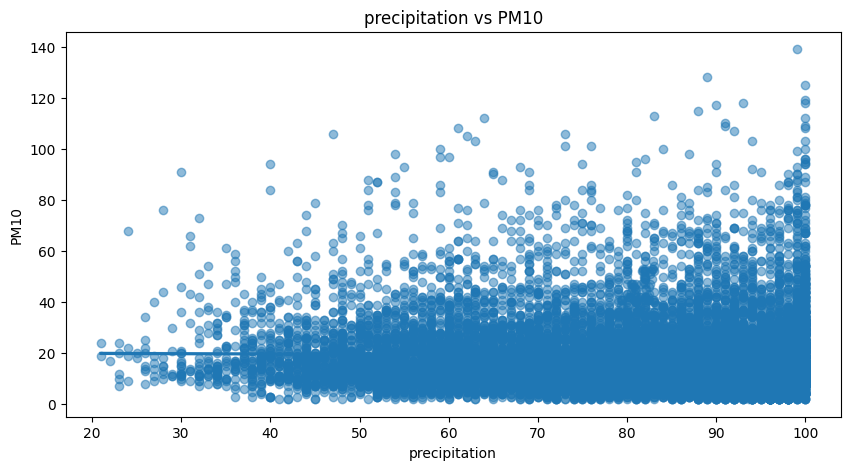

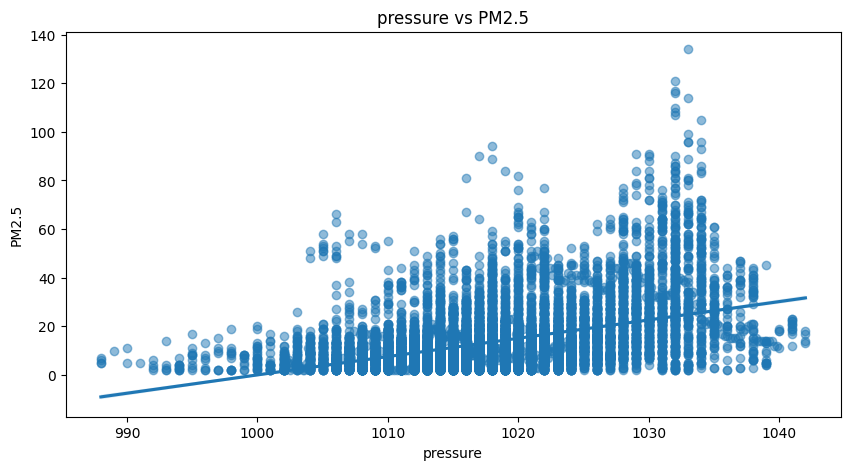

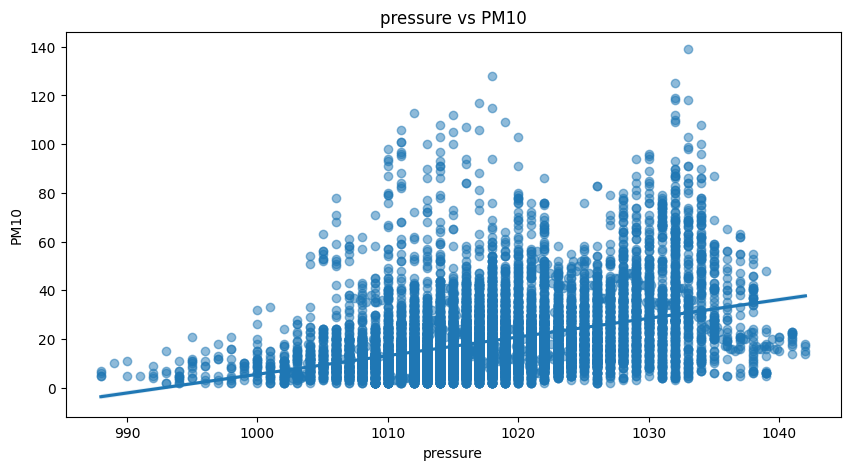

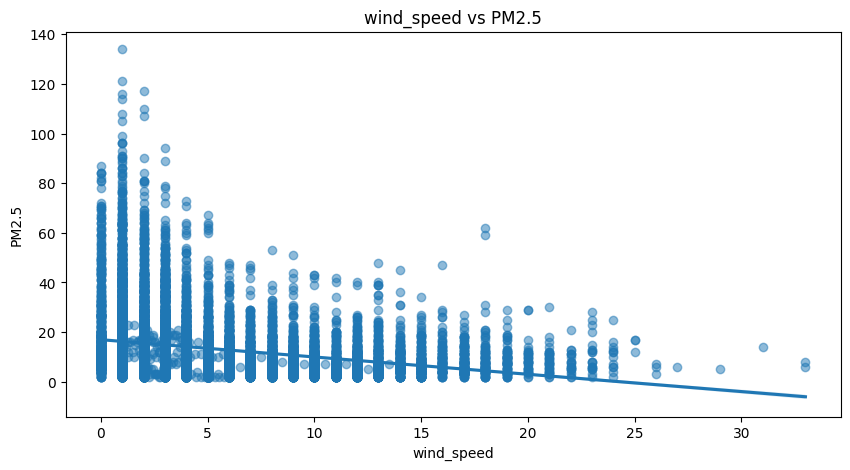

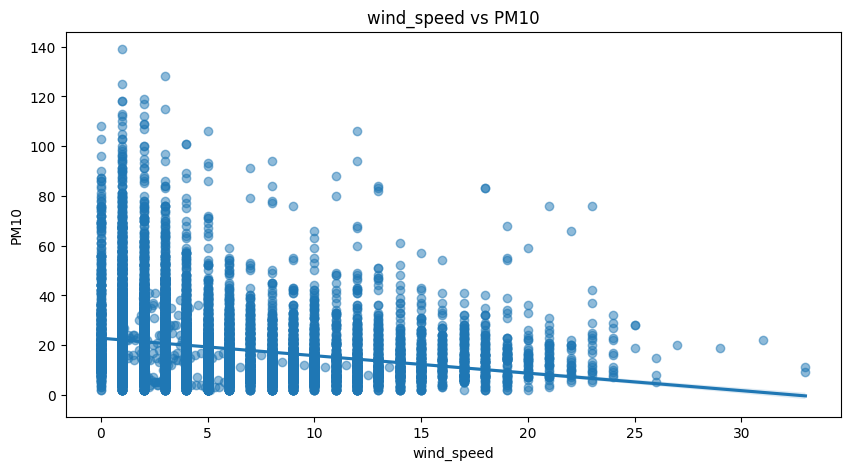

In [ ]:
# generate all regression graphs
for variable in weather:
    regression_plot(variable, "PM2.5")
    regression_plot(variable, "PM10")

In [ ]:
# now i need to use linear regression model to get slope, intercept and R squared.
regression_results=[]
for variable in weather:
    for target in targets:
        X = df[[variable]]
        y = df[target]
        model = LinearRegression()
        model.fit(X, y)
        prediction = model.predict(X)
        r2 = r2_score(y, prediction)
        mae = mean_absolute_error(y, prediction) # this is mean absolute error and it tells the average prediction error.
        # the result will be long so i can use multiple lines.
        regression_results.append({"Independent Variable":variable,
            "Dependent Variable":target,
            "Slope":model.coef_[0],
            "Intercept":model.intercept_,
            "R²":r2,
            "MAE":mae})

regression_table = pd.DataFrame(regression_results)
regression_table

,Independent Variable,Dependent Variable,Slope,Intercept,R²,MAE
0,temperature,PM2.5,-0.576375,21.119812,0.170349,7.834497
1,temperature,PM10,-0.391649,24.449111,0.055383,10.218517
2,rain,PM2.5,-1.293201,13.719322,0.008173,8.331487
3,rain,PM10,-1.789809,19.570893,0.011023,10.361513
4,precipitation,PM2.5,0.094033,6.031907,0.017244,8.302085
5,precipitation,PM10,-0.011199,20.165424,0.000172,10.416990
6,pressure,PM2.5,0.754348,-754.381539,0.204365,7.399708
7,pressure,PM10,0.766820,-761.307241,0.148698,9.438055
8,wind_speed,PM2.5,-0.696716,16.964424,0.069009,8.096048
9,wind_speed,PM10,-0.702958,22.764978,0.049466,10.173458


In [ ]:
# now i need to save and download tables for appendix section
descriptive_stats.to_csv("descriptive_statistics.csv")
correlation_results.to_csv("correlation_results.csv")
regression_table.to_csv("regression_results.csv")

files.download("descriptive_statistics.csv")
files.download("correlation_results.csv")
files.download("regression_results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>